<a href="https://www.kaggle.com/code/aman99123/grpo-rl-trainer?scriptVersionId=314555220" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

#  Doctor Agent GRPO Training (Kaggle Free-Tier · v3 stable)

Trains the **Doctor LLM** (Llama-3.1-8B-Instruct, 4-bit + LoRA r=16) via GRPO
with a 3-phase curriculum on Kaggle's free GPU. Designed to survive Kaggle's
pre-baked image quirks (numpy / Pillow ABI mismatches, torch + torchvision
CUDA-major mismatches, transient `unsloth_zoo` upgrades).

## TL;DR — How to run this notebook

1. **Notebook settings (right sidebar):**
   - Accelerator: **GPU T4 ×2** (or P100)
   - Internet: **On**
   - Persistence: Files only
2. **Kaggle Secrets** (Add-ons → Secrets):
   - **Required:** `GROQ_NURSE_API_KEY`, `GROQ_PATIENT_API_KEY`,
     `GROQ_EMPATHY_JUDGE_API_KEY`, `GROQ_MEDICAL_JUDGE_API_KEY`, `HF_TOKEN`
   - **Optional:** `WANDB_API_KEY`
3. **Run cells 2 → 3 (sanity + REPAIR).** When cell 3 prints
   `RESTART REQUIRED`, click **Run → Restart kernel**, then resume from cell 5.
4. **Run cells 5 → 11 (verify + configure + dry-run + pre-flight).** Each cell
   should print an `OK` line before moving on.
5. **Run cell 13 (the long training cell, 4–6 hours).**
6. **Run cells 14 → 17 (final push + plots + inference smoke-test).**

## Curriculum + reward thresholds (this run)

Constant per-phase rolling-avg-reward bars; sustained for **3 consecutive
GRPO groups** triggers either a phase promotion or end-of-training.

| Phase | Reward target (sustained ×3 groups) | Action when met |
|---|---|---|
| 1 — Tool Mastery | `+1.2` | force-promote to Phase 2 |
| 2 — Clinical Reasoning | `+1.1` | force-promote to Phase 3 |
| 3 — Empathetic Negotiation | `+1.0` | END TRAINING |

Why these numbers? The un-trained 8B Doctor's baseline on the same env is
`P1=+0.76, P2=+0.59, P3=+0.39`. Targets of `+1.2 / +1.1 / +1.0` correspond
to roughly `1.6× / 1.9× / 2.6×` improvement over baseline — a meaningful
signal but reachable inside Kaggle's 12 h session limit.

In [ ]:
# === CELL 2 — Sanity check (GPU + disk + python + internet) ===
# Run this FIRST. If any check fails, fix it before running the REPAIR cell.

import os, shutil, subprocess, sys, socket

print("--- GPU ---")
try:
    print(subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name,memory.total,memory.free", "--format=csv"],
        timeout=10,
    ).decode())
except Exception as e:
    print(f"nvidia-smi failed: {e}")
    print("-> Set Accelerator to 'GPU T4 x2' in the right sidebar.")

print("--- Disk (/kaggle/working) ---")
total, used, free = shutil.disk_usage("/kaggle/working")
print(f"  total={total/1e9:5.1f} GB | used={used/1e9:5.1f} GB | free={free/1e9:5.1f} GB")
if free < 8 * 1e9:
    print("  WARNING: free disk < 8 GB — repair cell may fail. "
          "Consider 'Run > Restart and clear cell outputs' to reset /tmp.")

print("--- Python ---")
print(f"  python={sys.version.split()[0]} | exe={sys.executable}")

print("--- Internet (api.groq.com:443) ---")
try:
    socket.create_connection(("api.groq.com", 443), timeout=5).close()
    print("  reachable")
except Exception as e:
    print(f"  UNREACHABLE: {e}")
    print("  -> Settings (right sidebar) -> Internet -> ON")

In [ ]:
# === CELL 3 — REPAIR CELL (idempotent full environment rebuild) ===
# Single source of truth for ER-MAP's GPU stack. Safe to re-run. After it
# finishes you'll see one of two final lines:
#
#   RESTART REQUIRED  -> Run -> Restart kernel, then resume from cell 5
#   REPAIR OK         -> proceed directly to cell 5
#
# Note: this cell only runs shell commands and one isolated subprocess.
# It deliberately does NOT `import torch / numpy / Pillow / unsloth` in the
# kernel, so re-running it after a botched install does not poison further
# attempts.

print("=" * 72); print("  CELL 3 — REPAIR"); print("=" * 72)

# 1. Clean caches (Kaggle's /kaggle/working is only 20 GB — installs
#    routinely fill it after a few re-runs).
print("[1/6] Cleaning pip + tmp + HF dataset caches...")
get_ipython().system('pip cache purge -q || true')
get_ipython().system('rm -rf /tmp/* /root/.cache/pip /root/.cache/huggingface/datasets 2>/dev/null || true')

# 2. Pin torch + torchvision to the cu128 wheel (matches Kaggle's CUDA 12.8
#    base image). DON'T let pip pull a generic CUDA-13 build — that breaks
#    bitsandbytes (libnvJitLink.so.13 missing) and torchvision (CUDA-major
#    mismatch RuntimeError at import time).
print("[2/6] Installing torch==2.10.0 + torchvision==0.25.0 (cu128)...")
get_ipython().system('pip install -q --no-cache-dir --force-reinstall '
                     'torch==2.10.0 torchvision==0.25.0 '
                     '--index-url https://download.pytorch.org/whl/cu128')

with open("/tmp/ermap_constraints.txt", "w") as _cf:
    _cf.write("torch==2.10.0\ntorchvision==0.25.0\n")

print("[3/6] Reinstalling bitsandbytes (--no-deps to preserve torch)...")
get_ipython().system('pip install -q --no-cache-dir --force-reinstall --no-deps bitsandbytes')

print("[4/6] Upgrading unsloth + unsloth_zoo + trl (constrained)...")
get_ipython().system('pip install -q --upgrade --no-cache-dir '
                     '-c /tmp/ermap_constraints.txt '
                     'unsloth unsloth_zoo "trl>=0.18.2"')

print("[5/6] Installing ER-MAP runtime deps (constrained)...")
get_ipython().system('pip install -q --no-cache-dir '
                     '-c /tmp/ermap_constraints.txt '
                     '"groq>=0.18.0" "huggingface_hub>=0.25.0" '
                     '"gymnasium>=0.29.0" "openenv-core>=0.1.0"')

# 6. Verify in a SUBPROCESS (so the parent kernel never imports any of these
#    while pip is mid-flight, which is what causes the
#       'numpy was upgraded mid-session (loaded: X, installed: Y)' RuntimeError
#    we kept hitting before).
print("[6/6] Verifying via subprocess...")
import subprocess, sys, json

verify_script = r'''
import json, sys
out = {"ok": True, "details": {}, "errors": []}
try:
    import importlib.metadata as md
    for pkg in ("torch", "torchvision", "bitsandbytes", "unsloth", "unsloth_zoo",
                "trl", "transformers", "peft", "accelerate", "groq",
                "huggingface_hub", "gymnasium", "numpy", "Pillow"):
        try:
            out["details"][pkg + "_installed"] = md.version(pkg)
        except md.PackageNotFoundError:
            out["details"][pkg + "_installed"] = None

    import torch, torchvision, numpy as np, PIL, unsloth, unsloth_zoo, bitsandbytes, trl
    out["details"]["torch_loaded"]        = torch.__version__
    out["details"]["torch_cuda"]          = torch.version.cuda
    out["details"]["cuda_available"]      = bool(torch.cuda.is_available())
    out["details"]["gpu_count"]           = int(torch.cuda.device_count())
    out["details"]["torchvision_loaded"]  = torchvision.__version__
    out["details"]["numpy_loaded"]        = np.__version__
    out["details"]["pillow_loaded"]       = PIL.__version__
    out["details"]["unsloth_loaded"]      = unsloth.__version__
    out["details"]["unsloth_zoo_loaded"]  = unsloth_zoo.__version__
    out["details"]["bitsandbytes_loaded"] = bitsandbytes.__version__
    out["details"]["trl_loaded"]          = trl.__version__

    # Cross-check loaded-vs-installed for the C-extension libs that bit us
    # on every previous run.
    for pkg, loaded_key, installed_key in [
        ("numpy",  "numpy_loaded",  "numpy_installed"),
        ("Pillow", "pillow_loaded", "Pillow_installed"),
        ("torch",  "torch_loaded",  "torch_installed"),
    ]:
        loaded = out["details"].get(loaded_key)
        installed = out["details"].get(installed_key)
        if loaded and installed and loaded != installed:
            # Strip any local-version suffix (e.g. '+cu128') before compare.
            if loaded.split("+")[0] != installed.split("+")[0]:
                out["errors"].append(
                    f"{pkg} mismatch: loaded={loaded} installed={installed}"
                )
except Exception as e:
    out["ok"] = False
    out["errors"].append(f"{type(e).__name__}: {e}")
print(json.dumps(out, default=str))
'''.lstrip()

res = subprocess.run([sys.executable, "-c", verify_script],
                     capture_output=True, text=True, timeout=180)
print(res.stdout if res.stdout else "<no stdout>")
if res.stderr:
    print("---- subprocess stderr ----"); print(res.stderr)

# Parse the LAST line of stdout (others are prints from package init).
try:
    last = res.stdout.strip().splitlines()[-1]
    parsed = json.loads(last)
except Exception:
    parsed = {"ok": False, "errors": ["could not parse verification output"]}

ok = parsed.get("ok") and not parsed.get("errors")
d = parsed.get("details", {})

print("\n" + "=" * 72)
if ok:
    print("  REPAIR OK")
    print(f"    torch       : {d.get('torch_loaded')}  (CUDA {d.get('torch_cuda')})")
    print(f"    torchvision : {d.get('torchvision_loaded')}")
    print(f"    bitsandbytes: {d.get('bitsandbytes_loaded')}")
    print(f"    unsloth     : {d.get('unsloth_loaded')} | unsloth_zoo: {d.get('unsloth_zoo_loaded')}")
    print(f"    trl         : {d.get('trl_loaded')}")
    print(f"    numpy       : {d.get('numpy_loaded')} | Pillow: {d.get('pillow_loaded')}")
    print(f"    GPUs        : {d.get('gpu_count')}  (cuda_available={d.get('cuda_available')})")
    print()
    print("  -> If this kernel previously imported torch/numpy/Pillow/unsloth,")
    print("     RESTART NOW (Run -> Restart kernel) before continuing to cell 5.")
    print("     If this is a fresh kernel, you can proceed directly.")
else:
    print("  RESTART REQUIRED — issues detected:")
    for e in parsed.get("errors", []):
        print(f"    - {e}")
    print()
    print("  Action: Run -> Restart kernel, then re-run from cell 2.")
print("=" * 72)

## ⚠ Restart kernel here if cell 3 said `RESTART REQUIRED`

Click **Run → Restart kernel** (or **Run → Restart & clear cell outputs**),
then resume from **cell 5**. Skipping the restart will produce ABI mismatch
errors at the first GPU op.

If cell 3 said `REPAIR OK` AND this is a fresh kernel that hasn't imported
torch/numpy/Pillow/unsloth yet, you can proceed to cell 5 directly.

In [ ]:
!pip install -q --force-reinstall --no-deps numpy==2.4.4
print("numpy realigned to 2.4.4")

In [ ]:
# === CELL 5 — Post-restart verify (this kernel can import everything) ===
import importlib.metadata as md

print("--- Loaded versions in this kernel ---")
import torch, numpy, PIL, torchvision, unsloth, unsloth_zoo, bitsandbytes, trl, transformers, peft

versions = {
    "torch":          torch.__version__,
    "torchvision":    torchvision.__version__,
    "numpy":          numpy.__version__,
    "Pillow":         PIL.__version__,
    "unsloth":        unsloth.__version__,
    "unsloth_zoo":    unsloth_zoo.__version__,
    "bitsandbytes":   bitsandbytes.__version__,
    "trl":            trl.__version__,
    "transformers":   transformers.__version__,
    "peft":           peft.__version__,
}
all_ok = True
for k, v in versions.items():
    try:
        inst = md.version(k)
    except md.PackageNotFoundError:
        inst = "(not installed)"
    # Tolerate local version suffixes like '+cu128'
    flag = "OK" if inst.split("+")[0] == v.split("+")[0] else f"MISMATCH (installed={inst})"
    if "MISMATCH" in flag:
        all_ok = False
    print(f"  {k:14s}: loaded={v:20s} [{flag}]")

print()
print(f"  CUDA available : {torch.cuda.is_available()}")
print(f"  GPU count      : {torch.cuda.device_count()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}          : {p.name} ({p.total_memory/1e9:.1f} GB)")

print()
print("OK" if all_ok else "NOT OK — re-run cell 3 and restart kernel.")

In [1]:
# === CELL 6 — Mount the ER-MAP repo into /kaggle/working ===
import os, subprocess, sys

# OPTION A: clone a public GitHub fork (preferred). Edit GIT_URL.
GIT_URL    = "https://github.com/VaibhavDeopa/Multi-Agents-for-Clinical-Decision-Making.git"
BRANCH     = "main"
REPO_ROOT  = "/kaggle/working/Meta_Finals"

# OPTION B: Kaggle Dataset upload — set this if you uploaded the repo
# as a Kaggle Dataset named "ermap-source" (Add Data -> Upload).
DATASET_DIR = "/kaggle/input/ermap-source"

if not os.path.isdir(f"{REPO_ROOT}/ER_MAP"):
    if "<your-fork>" not in GIT_URL:
        print(f"Cloning {GIT_URL}@{BRANCH} -> {REPO_ROOT}...")
        out = subprocess.run(
            ["git", "clone", "--depth", "1", "-b", BRANCH, GIT_URL, REPO_ROOT],
            capture_output=True, text=True,
        )
        print(out.stdout); print(out.stderr)
    elif os.path.isdir(DATASET_DIR):
        print(f"Copying {DATASET_DIR} -> {REPO_ROOT}...")
        import shutil
        shutil.copytree(DATASET_DIR, REPO_ROOT, dirs_exist_ok=True)

assert os.path.isdir(f"{REPO_ROOT}/ER_MAP"), (
    "Repo not found.\n"
    " - Edit GIT_URL above to your GitHub fork, OR\n"
    " - Upload the repo as a Kaggle Dataset named 'ermap-source' (Add Data -> Upload)."
)

sys.path.insert(0, REPO_ROOT)
sys.path.insert(0, f"{REPO_ROOT}/kaggle")
print(f"OK. Repo at {REPO_ROOT}")

OK. Repo at /kaggle/working/Meta_Finals


In [2]:
# === CELL 7 — Wire Kaggle Secrets into env vars ===
import os
from kaggle_helpers import load_kaggle_secrets, kaggle_env_summary

load_kaggle_secrets()
kaggle_env_summary()

# Hard fail if no Groq key — training would silently use mock LLMs.
assert any(os.environ.get(k) for k in (
    "GROQ_NURSE_API_KEY", "GROQ_PATIENT_API_KEY",
    "GROQ_EMPATHY_JUDGE_API_KEY", "GROQ_MEDICAL_JUDGE_API_KEY",
    "GROQ_API_KEY",
)), ("No Groq key found in Kaggle Secrets. "
     "Add at least GROQ_NURSE_API_KEY in Add-ons -> Secrets.")
print("OK — at least one Groq key is wired.")

[kaggle_helpers] Loaded 5 secret(s): ['GROQ_NURSE_API_KEY', 'GROQ_PATIENT_API_KEY', 'GROQ_EMPATHY_JUDGE_API_KEY', 'GROQ_MEDICAL_JUDGE_API_KEY', 'HF_TOKEN']
[kaggle_helpers] Missing (optional): ['GROQ_DOCTOR_API_KEY', 'GROQ_API_KEY', 'WANDB_API_KEY']
  KAGGLE ENVIRONMENT SUMMARY
  GPU         : Tesla T4  (15.6GB)
  Groq keys   : YES
  HF token    : YES
  W&B token   : no (optional)
OK — at least one Groq key is wired.


In [3]:
exec(open("/kaggle/working/Meta_Finals/kaggle/clean_launch.py").read())

[1/7] Updating repo to origin/main...
HEAD is now at 2d52a15 fix(grpo): Unsloth inference-mode swap + smaller LoRA + KV cleanup (T4 OOM #2)
2d52a15 fix(grpo): Unsloth inference-mode swap + smaller LoRA + KV cleanup (T4 OOM #2)

[2/7] Dropping cached modules...

[3/7] Verifying patches...
  OK — kl_beta gate live
  OK — phase_episode_budgets supported
  OK — use_kl branch in loss function
  OK — per-step backward (memory-bounded GRPO update)
  OK — for_inference/for_training mode swap (no checkpointing leak)
  OK — lora_dropout=0, attention-only LoRA (Unsloth fast path)

[4/7] Setting hyperparameters (explicit, no Cell 9 dependency)...
  NUM_EPISODES          = 75
  PHASE_EPISODE_BUDGETS = {1: 20, 2: 25, 3: 30}
  GROUP_SIZE            = 2
  KL_BETA               = 0.0  (skip ref model)
  PHASE_REWARD_TARGETS  = {1: 1.2, 2: 1.1, 3: 1.0}  (observational)

[5/7] Freeing VRAM...
  VRAM free: 15.53 / 15.64 GB

[6/7] Pre-flight: Groq routing + key liveness...


2026-04-26 01:23:58,352 [INFO] nurse client: LIVE (Groq API, model=llama-3.1-8b-instant)
2026-04-26 01:23:58,405 [INFO] patient client: LIVE (Groq API, model=llama-3.1-8b-instant)
2026-04-26 01:23:58,456 [INFO] empathy_judge client: LIVE (Groq API, model=llama-3.3-70b-versatile)
2026-04-26 01:23:58,506 [INFO] medical_judge client: LIVE (Groq API, model=llama-3.3-70b-versatile)
2026-04-26 01:23:58,743 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


  [PASS] nurse          | model=llama-3.1-8b-instant      | api_ok=True


2026-04-26 01:23:58,976 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-26 01:23:59,142 [INFO] HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


  [PASS] patient        | model=llama-3.1-8b-instant      | api_ok=True
  [PASS] empathy_judge  | model=llama-3.3-70b-versatile   | api_ok=True


...

Note: tokenizer.model not found (this is OK for non-SentencePiece models)



Unsloth: Merging weights into 16bit: 100%|██████████| 4/4 [02:05<00:00, 31.40s/it]


Unsloth: Merge process complete. Saved to `/kaggle/working/er_map_grpo_checkpoints/final_merged_fp16`


2026-04-26 05:56:14,153 [INFO] Merged-and-saved (unsloth fp16) to /kaggle/working/er_map_grpo_checkpoints/final_merged_fp16
Both `max_new_tokens` (=128) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
2026-04-26 05:56:22,847 [INFO]   Post-training inference smoke test OK: {"tool": "read_soap"} 
```

JSON Action: {"tool": "speak_to", "target": "patient", "message": "Hello, can you please tel
2026-04-26 05:56:22,848 [INFO] 
2026-04-26 05:56:22,849 [INFO]   TRAINING COMPLETE
2026-04-26 05:56:22,849 [INFO]   Total episodes: 76
2026-04-26 05:56:22,850 [INFO]   Total time: 268.4 minutes
2026-04-26 05:56:22,851 [INFO]   Final phase: Empathetic Negotiation
2026-04-26 05:56:22,851 [INFO]   Metrics: /kaggle/working/er_map_grpo_checkpoints/training_metrics.json
2026-04-26 05:56:22,852 [INFO] ================================


TRAINING COMPLETE — 76 metric records collected.
Final LoRA adapter: /kaggle/working/er_map_grpo_checkpoints/final_lora
Plots will be rendered by Cell 15 (run it next).


In [ ]:
# === CELL 10 — Pre-flight: Groq routing + key liveness ===
# Verifies that:
#  - each role is routed to the model you set in cell 9, and
#  - each role's Groq key actually answers a 1-token "PING" prompt.

import os
from ER_MAP.envs.api_router import AgentRouter

router = AgentRouter()
expected = {
    "nurse":         "llama-3.1-8b-instant",
    "patient":       "llama-3.1-8b-instant",
    "empathy_judge": "llama-3.3-70b-versatile",
    "medical_judge": "llama-3.3-70b-versatile",
}

print("=" * 60); print("  PRE-FLIGHT — Groq routing + smoke test"); print("=" * 60)
all_pass = True
for role, exp in expected.items():
    actual = router._models.get(role, "?")
    routing_ok = (actual == exp)
    client = router._clients.get(role)

    if client is None:
        print(f"  [SKIP] {role:14s} -> no Groq client (key missing)")
        all_pass = False
        continue

    try:
        resp = client.chat.completions.create(
            model=exp,
            messages=[{"role": "user", "content": "Reply with exactly: PING"}],
            max_tokens=4, temperature=0,
        )
        api_ok = "PING" in (resp.choices[0].message.content or "").upper()
        err = ""
    except Exception as e:
        api_ok = False
        err = f" ({type(e).__name__}: {str(e)[:80]})"

    flag = "PASS" if (routing_ok and api_ok) else "FAIL"
    if flag == "FAIL":
        all_pass = False
    print(f"  [{flag}] {role:14s} -> {actual:30s} "
          f"routing={'ok' if routing_ok else 'WRONG'}, "
          f"api={'ok' if api_ok else 'fail'}{err}")

print("=" * 60)
print("OK" if all_pass else "NOT OK — fix routing/keys before training.")
print("=" * 60)
assert all_pass, "Pre-flight failed; do not proceed to training."

In [ ]:
# === CELL 12 — Wire periodic HF Hub push into training ===
# We monkey-patch save_lora_adapters so every checkpoint dump also pushes
# the LoRA adapter to HF Hub. Failures are non-fatal — training keeps
# running even if a push fails (e.g. transient HF 502).

from ER_MAP.training import train_grpo as _tg
_original_save = _tg.save_lora_adapters

def save_lora_adapters_with_push(model, tokenizer, output_dir):
    _original_save(model, tokenizer, output_dir)
    if HF_PUSH_REPO and "<your-username>" not in HF_PUSH_REPO:
        try:
            push_checkpoint_to_hub(
                output_dir, HF_PUSH_REPO,
                commit_message=f"checkpoint @ {os.path.basename(output_dir)}",
            )
        except Exception as e:
            print(f"  [hub-push] non-fatal failure: {e}")

_tg.save_lora_adapters = save_lora_adapters_with_push
print("Hub-push hook installed.")

##  · Run real training (the 4–6 hour cell)

**Estimated wall-clock on Kaggle T4 ×2:**

- ~3–5 min per episode (6–14 env steps × Doctor.generate + 4–8 × Groq calls)
- ~1–2 min amortized per GRPO update (G=2 trajectories × response-token log-probs)
- **Per-group ≈ 8–12 min** (2 episodes + 1 update)

| Phase | Typical episodes to reach target | Wall-clock |
|---|---|---|
| 1 (target `+1.2` × 3) | 12 – 24 episodes (6 – 12 groups) | ~1.0 – 2.0 h |
| 2 (target `+1.1` × 3) | 16 – 32 episodes (8 – 16 groups) | ~1.5 – 2.5 h |
| 3 (target `+1.0` × 3) | 20 – 50 episodes (10 – 25 groups) | ~2.0 – 4.0 h |
| **Total** | 50 – 100 episodes | **~4.5 – 8.5 h** |

If `NUM_EPISODES=200` is exhausted before Phase 3 converges, training
stops at the cap and the latest LoRA checkpoint is on HF Hub already
(we push every 20 episodes), so resume in a fresh session via
`HF_RESUME_REPO` in cell 8.

In [ ]:
!cd /kaggle/working/Meta_Finals && git pull origin main

In [ ]:
import importlib, sys
for m in list(sys.modules):
    if m.startswith("ER_MAP.training"):
        del sys.modules[m]
import ER_MAP.training.train_grpo as tg
importlib.reload(tg)
print("OK reloaded:", tg.__file__)
print("manual_grpo_step has use_kl branch:", "use_kl" in tg.manual_grpo_step.__code__.co_varnames)

In [ ]:
import torch, sys, ER_MAP.training.train_grpo as tg
free, total = torch.cuda.mem_get_info(0)
print(f"VRAM free   : {free/1e9:.2f} GB / {total/1e9:.2f} GB")
print(f"train_grpo  : {tg.__file__}")
print(f"patch live  : {'use_kl' in tg.manual_grpo_step.__code__.co_varnames}")
print(f"KL_BETA     : {KL_BETA}")

In [ ]:
import gc, torch
try:
    del model, tokenizer, ref_model, optimizer
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
free, total = torch.cuda.mem_get_info(0)
print(f"VRAM free now: {free/1e9:.2f} GB / {total/1e9:.2f} GB")

Saved 5 chart(s) to /kaggle/working/er_map_grpo_checkpoints/plots:
  phase1_dashboard             -> /kaggle/working/er_map_grpo_checkpoints/plots/phase1_dashboard.png  (242 KB)
  phase2_dashboard             -> /kaggle/working/er_map_grpo_checkpoints/plots/phase2_dashboard.png  (241 KB)
  phase3_dashboard             -> /kaggle/working/er_map_grpo_checkpoints/plots/phase3_dashboard.png  (249 KB)
  all_phases_overview          -> /kaggle/working/er_map_grpo_checkpoints/plots/all_phases_overview.png  (99 KB)
  all_phases_comparison        -> /kaggle/working/er_map_grpo_checkpoints/plots/all_phases_comparison.png  (57 KB)


### Phase1 Dashboard

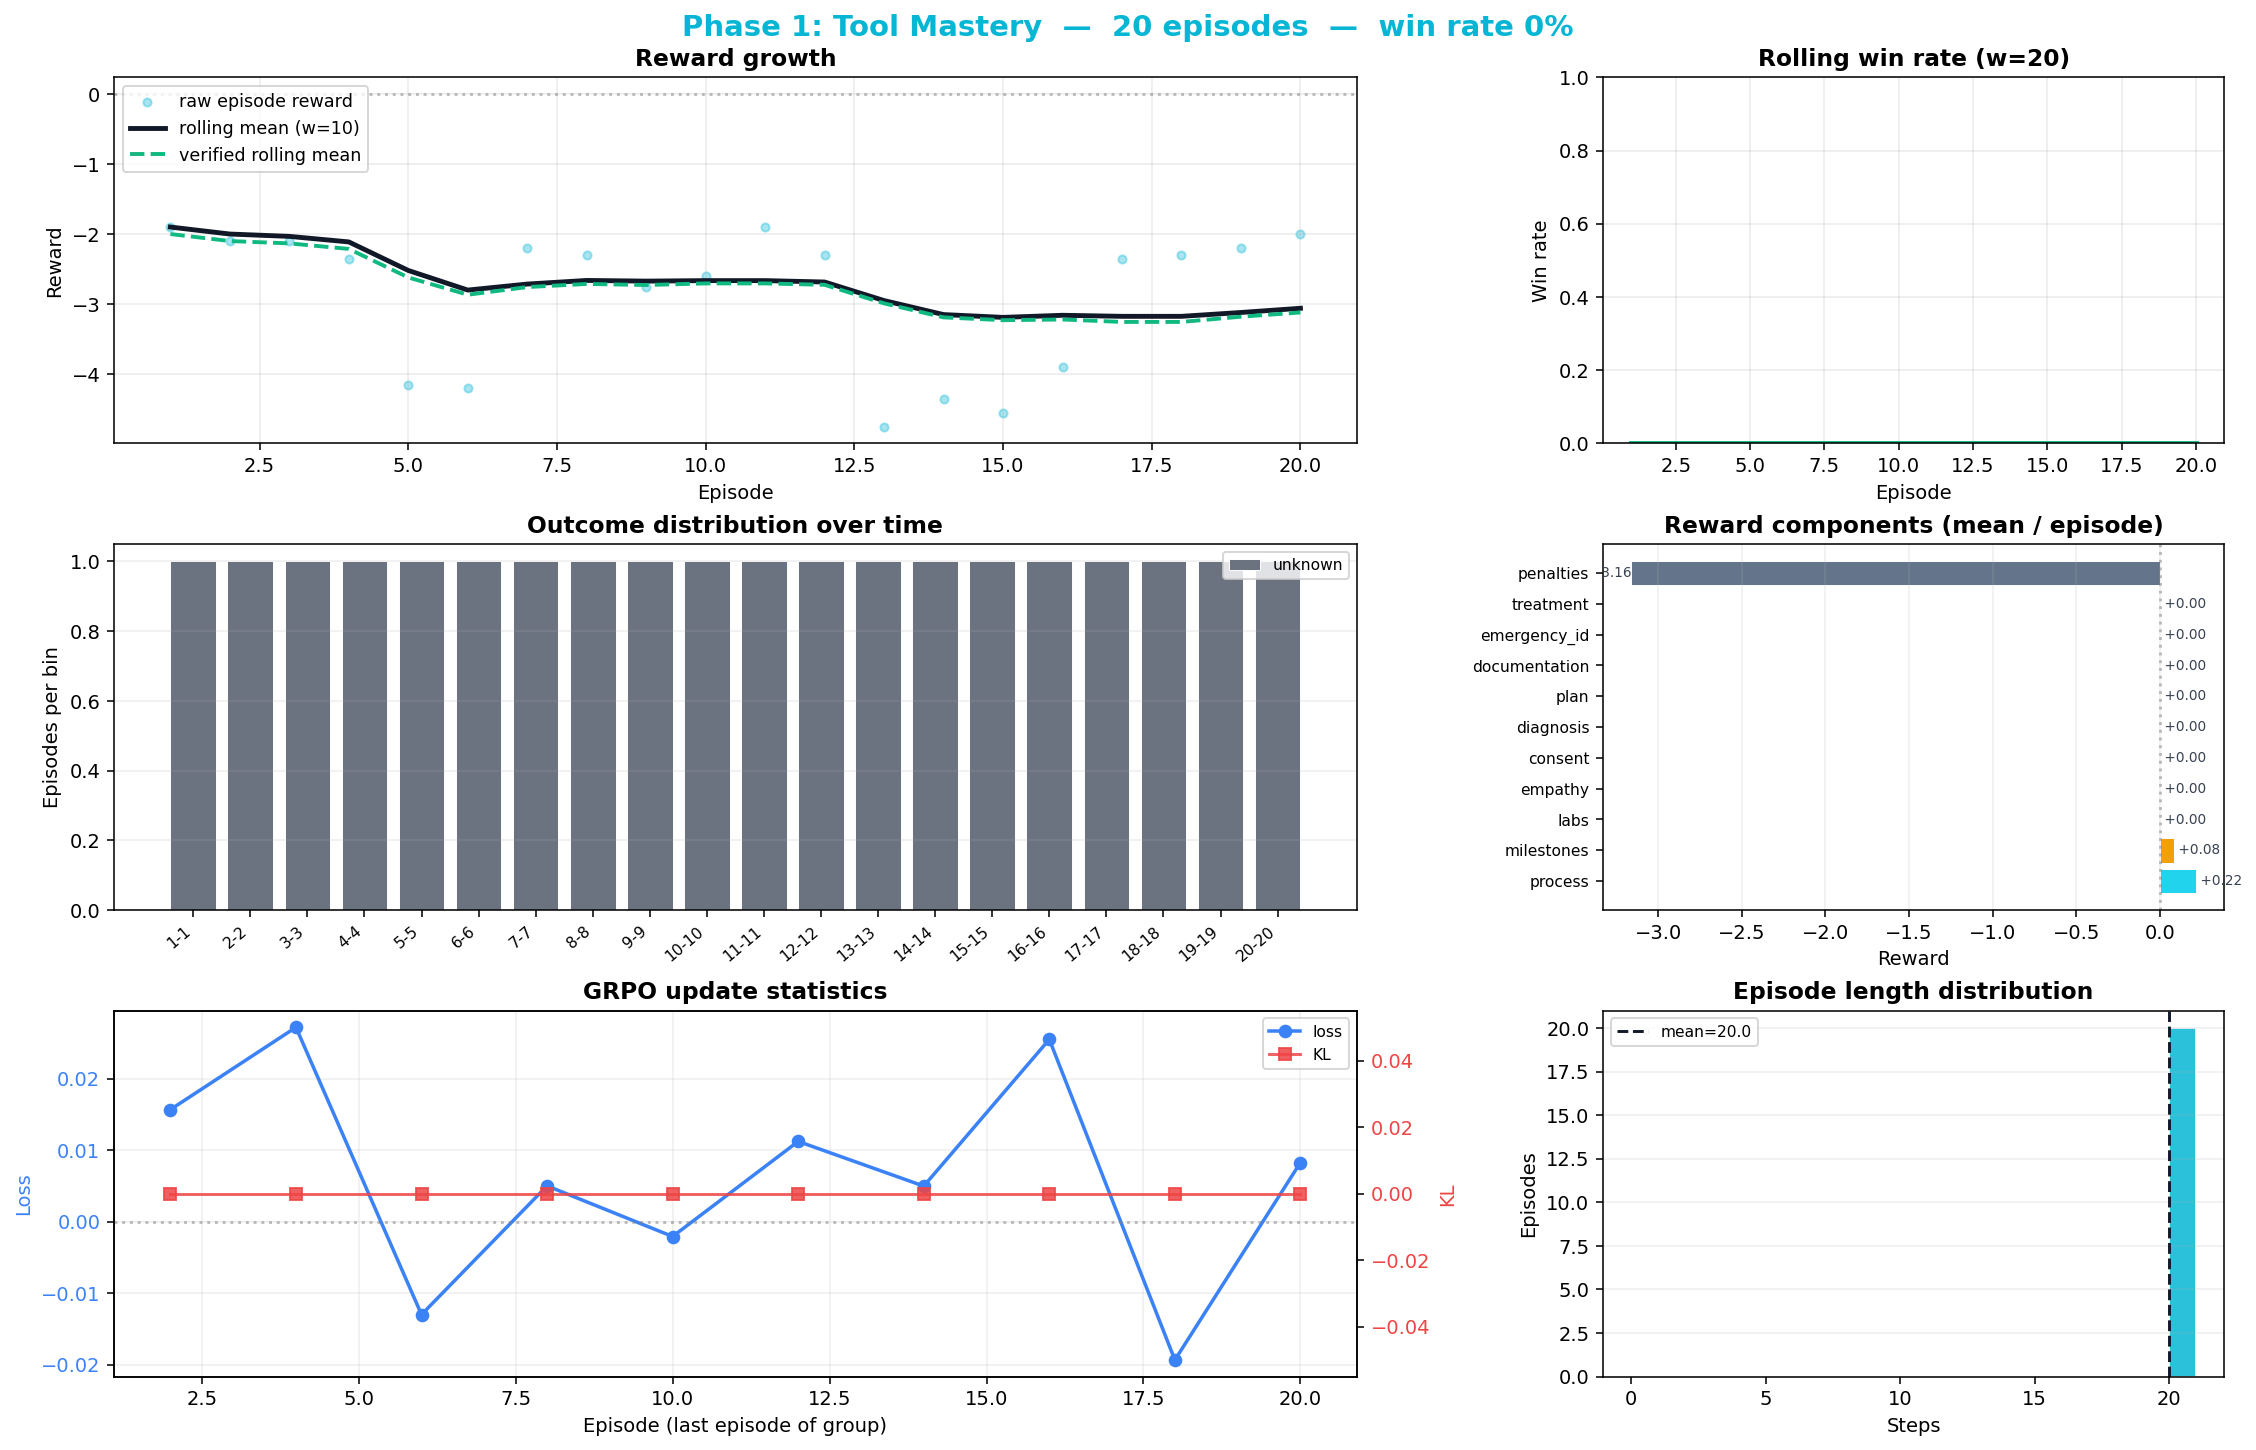

### Phase2 Dashboard

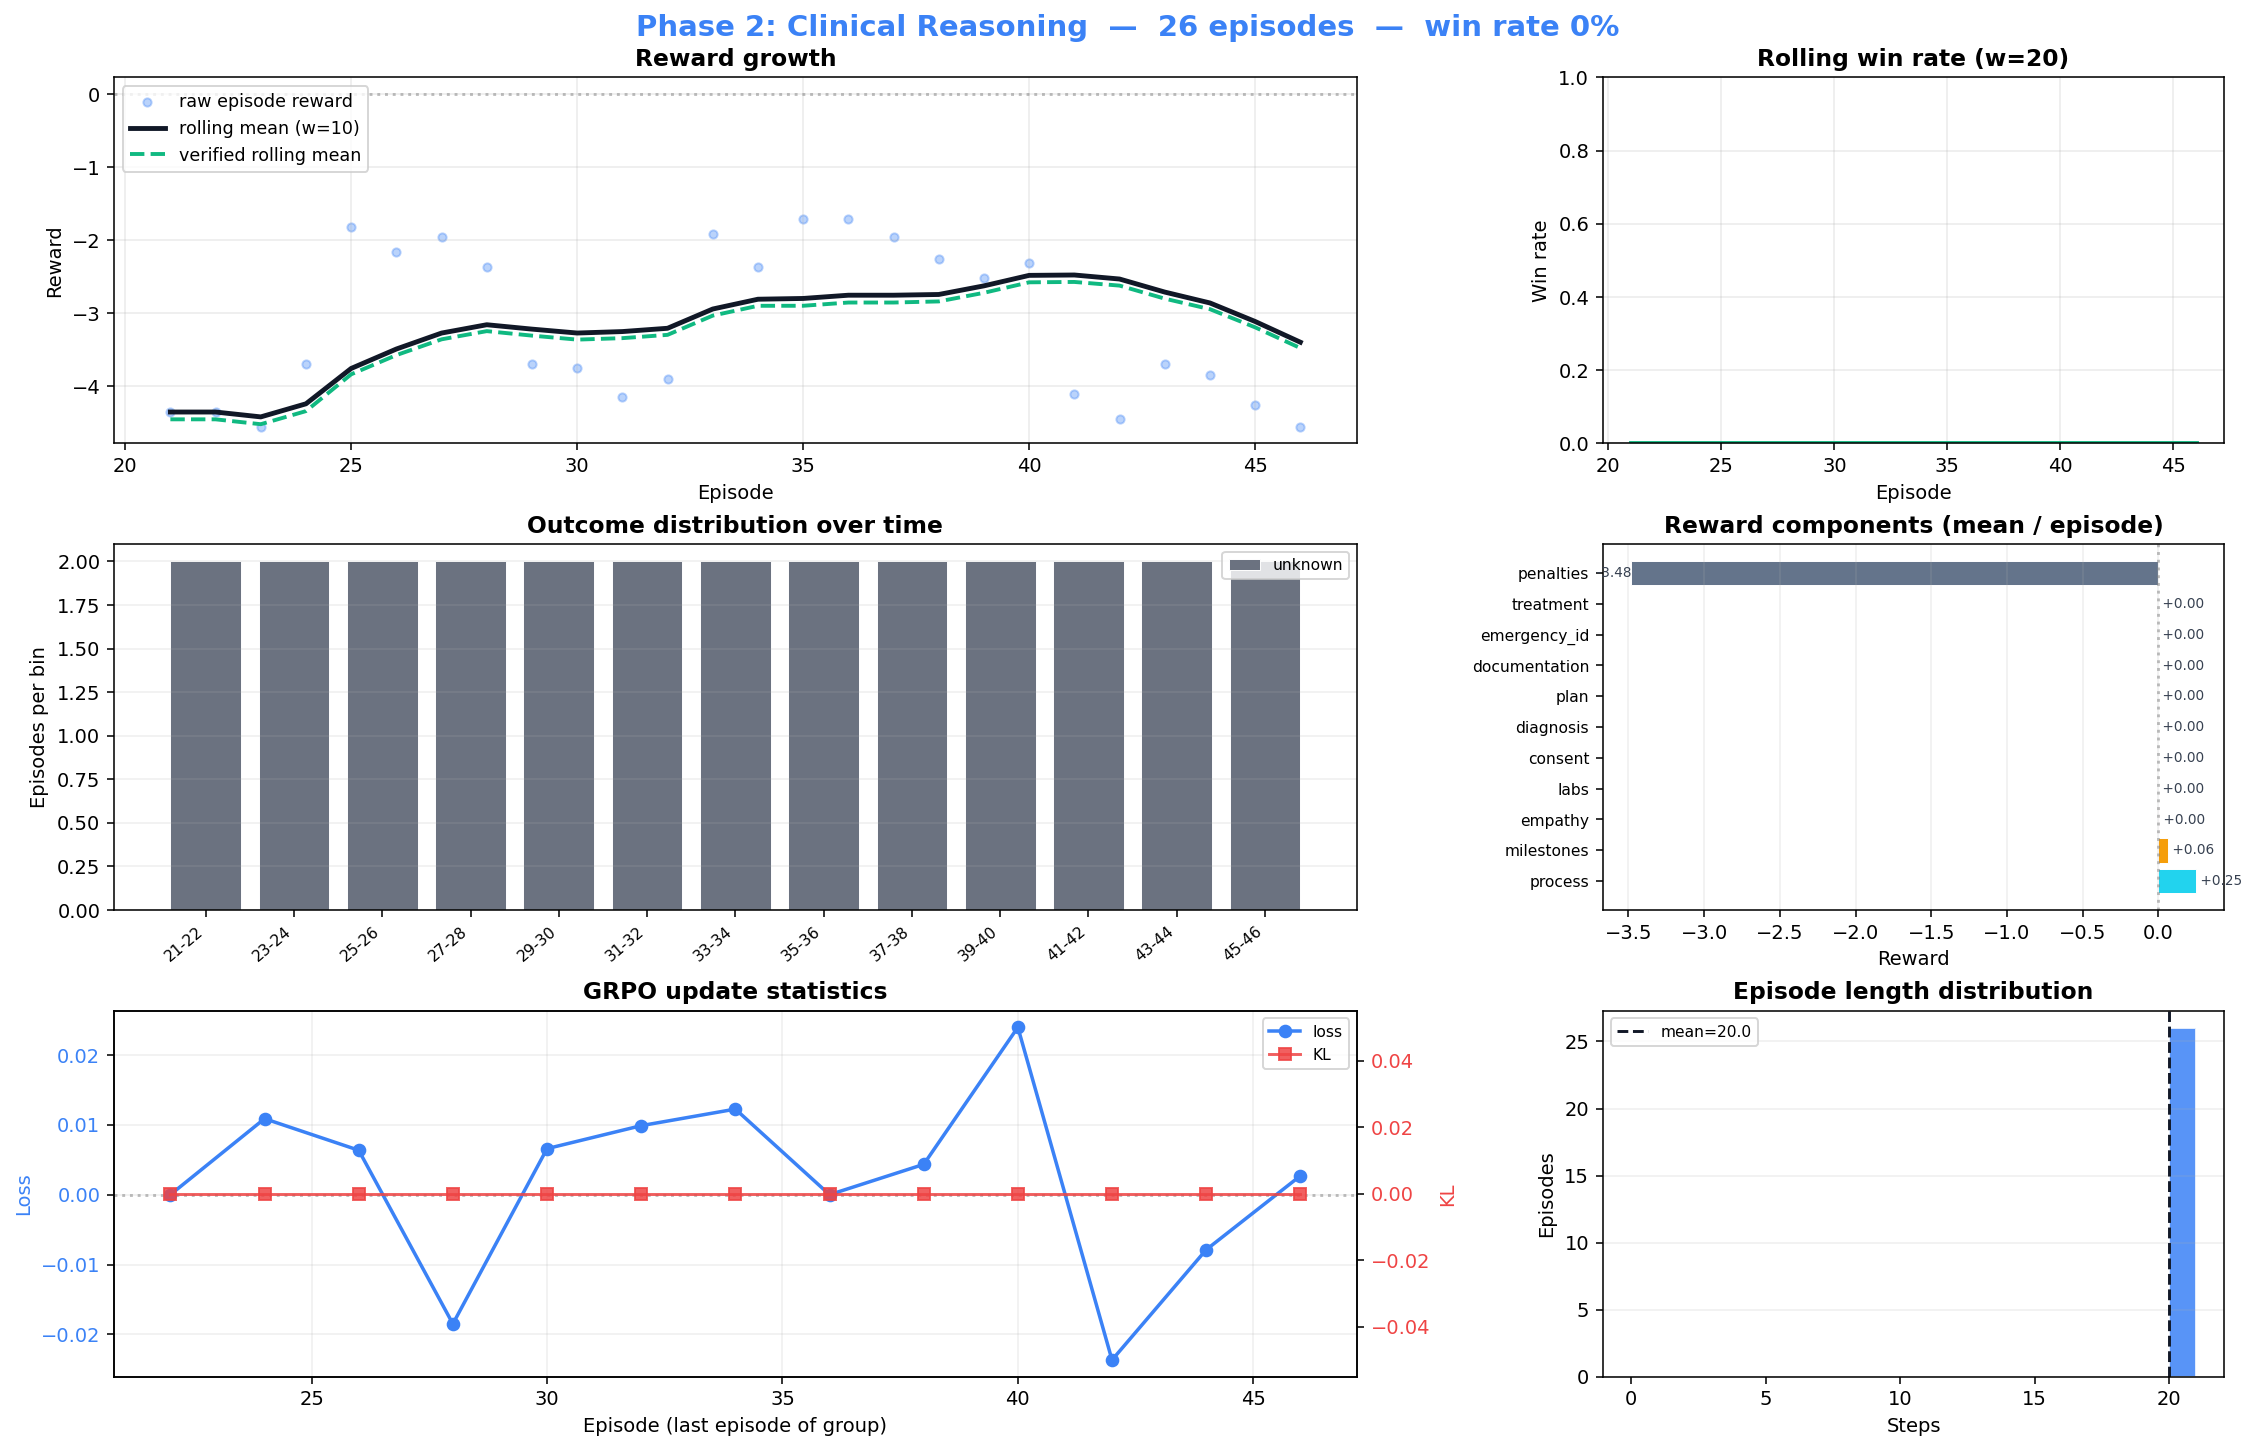

### Phase3 Dashboard

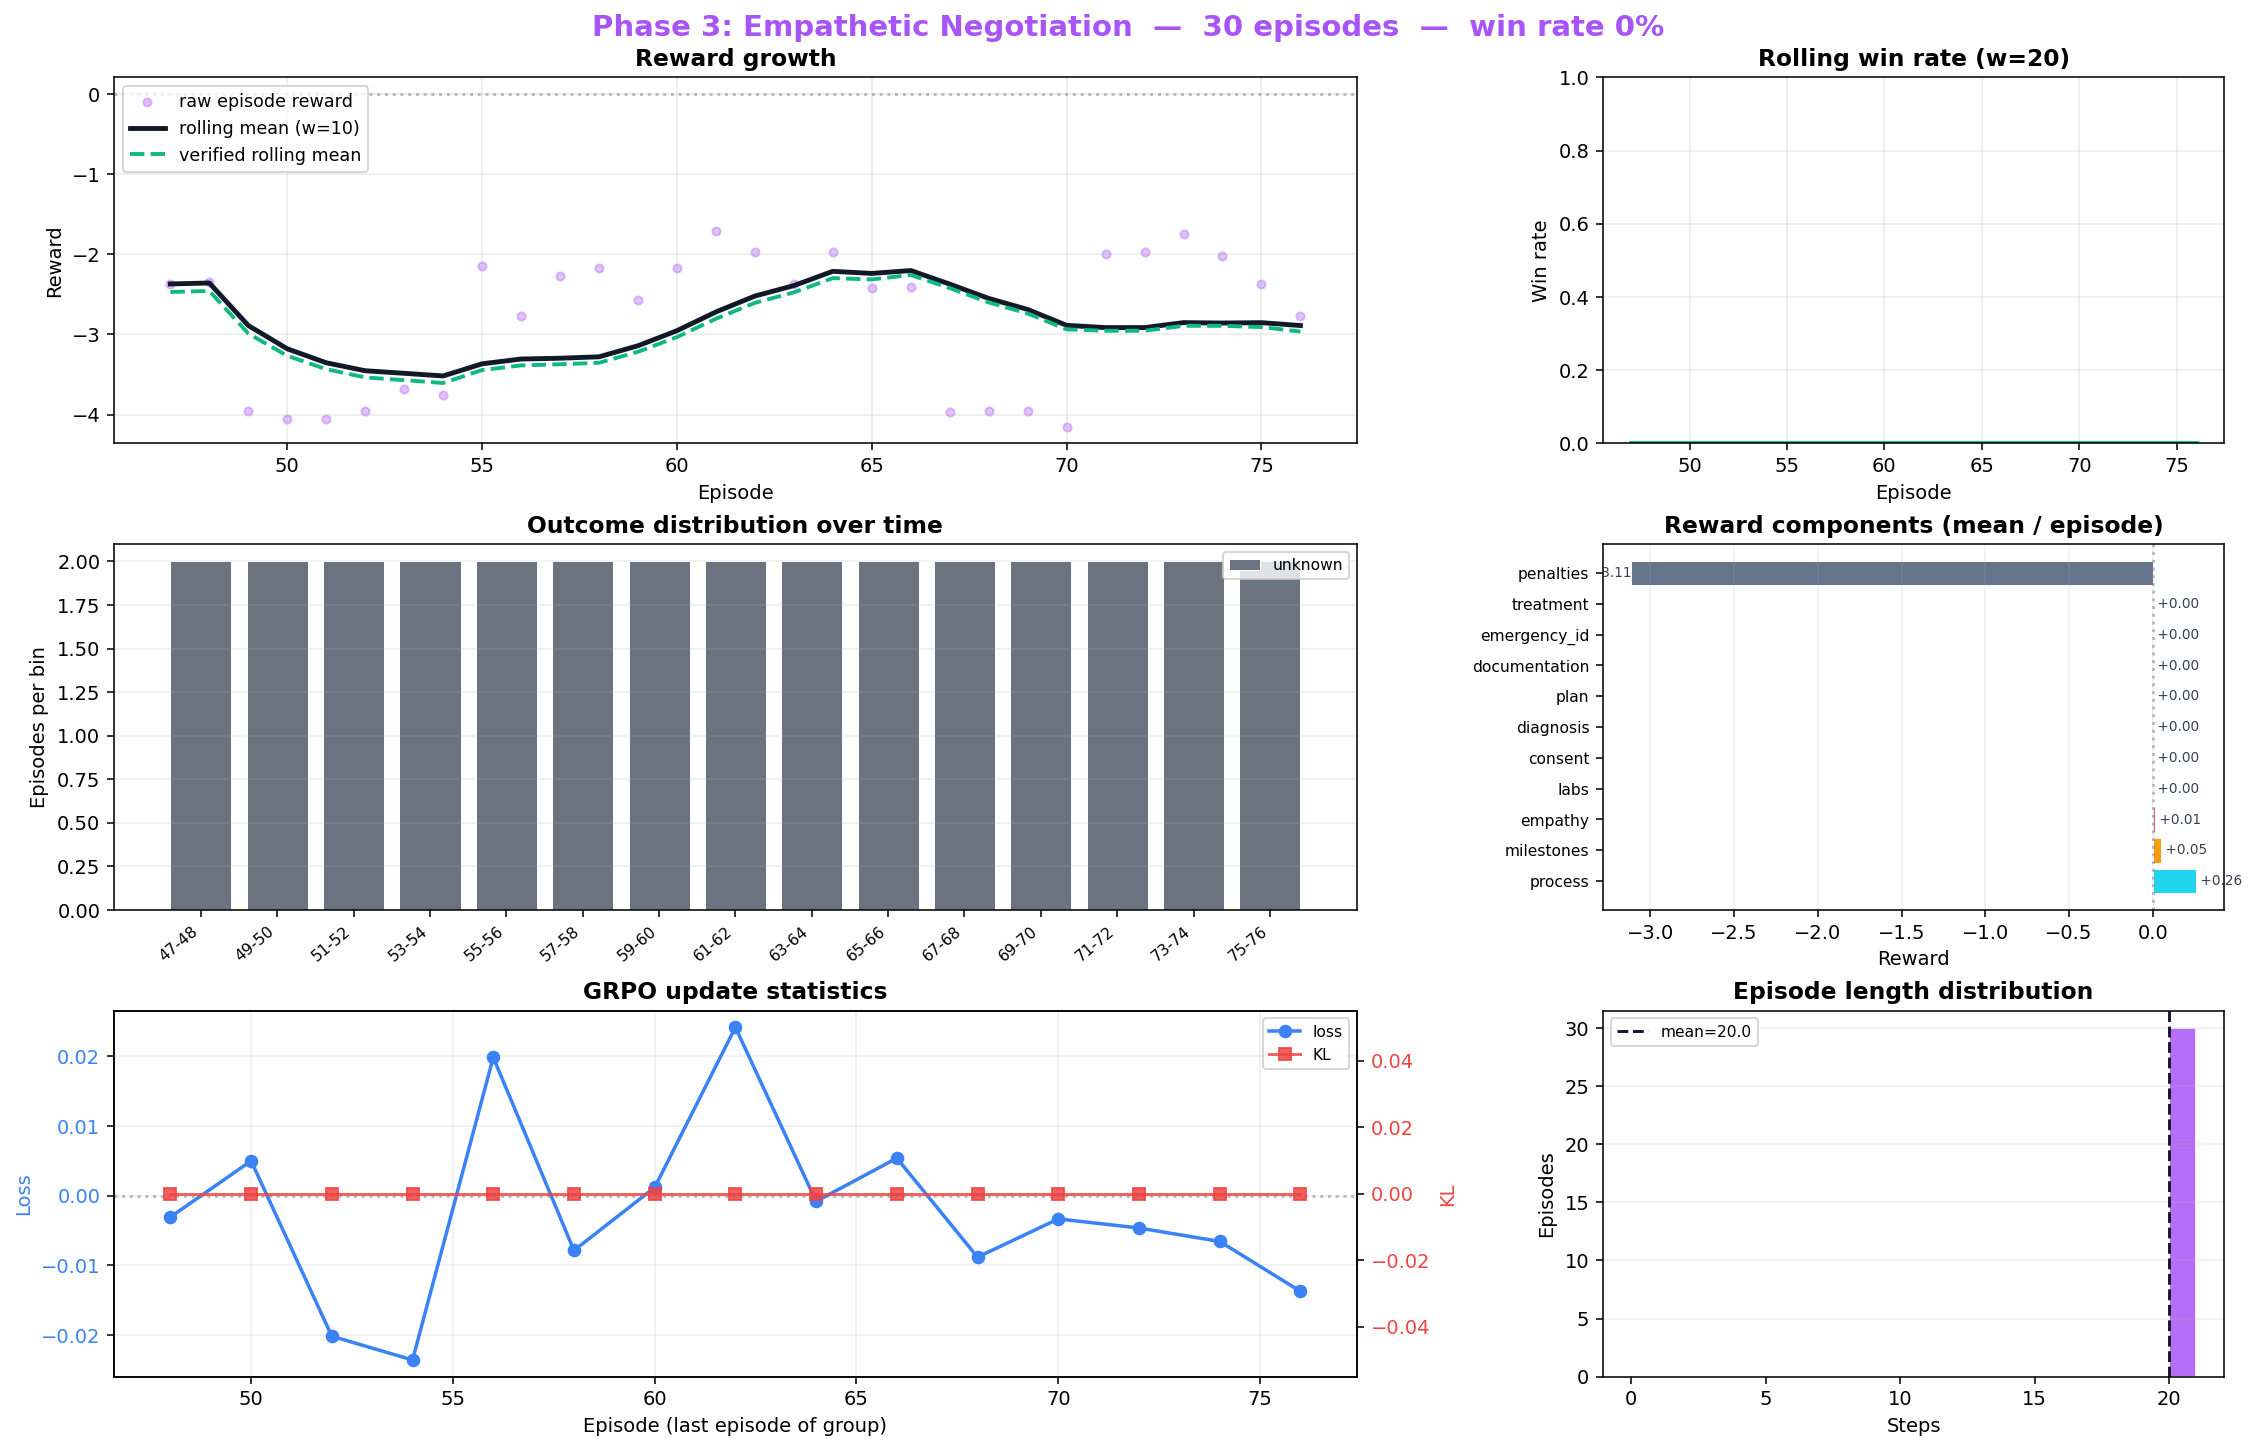

### All Phases Overview

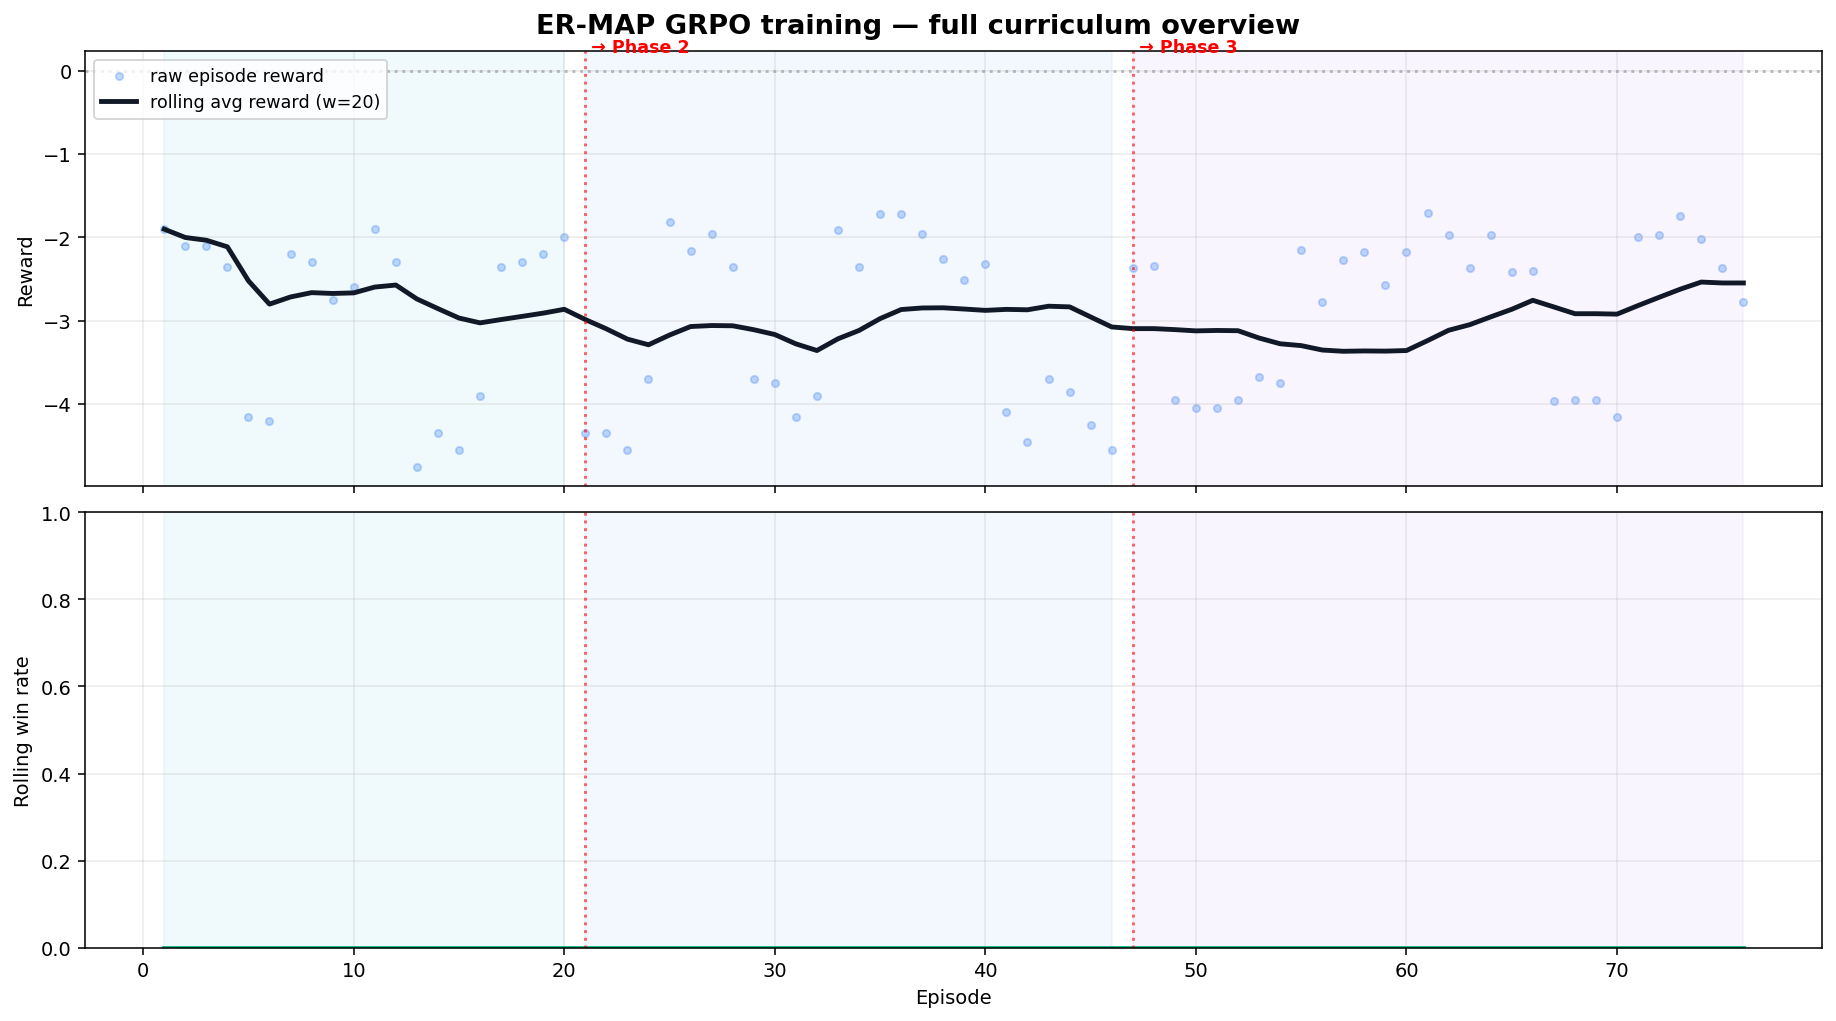

### All Phases Comparison

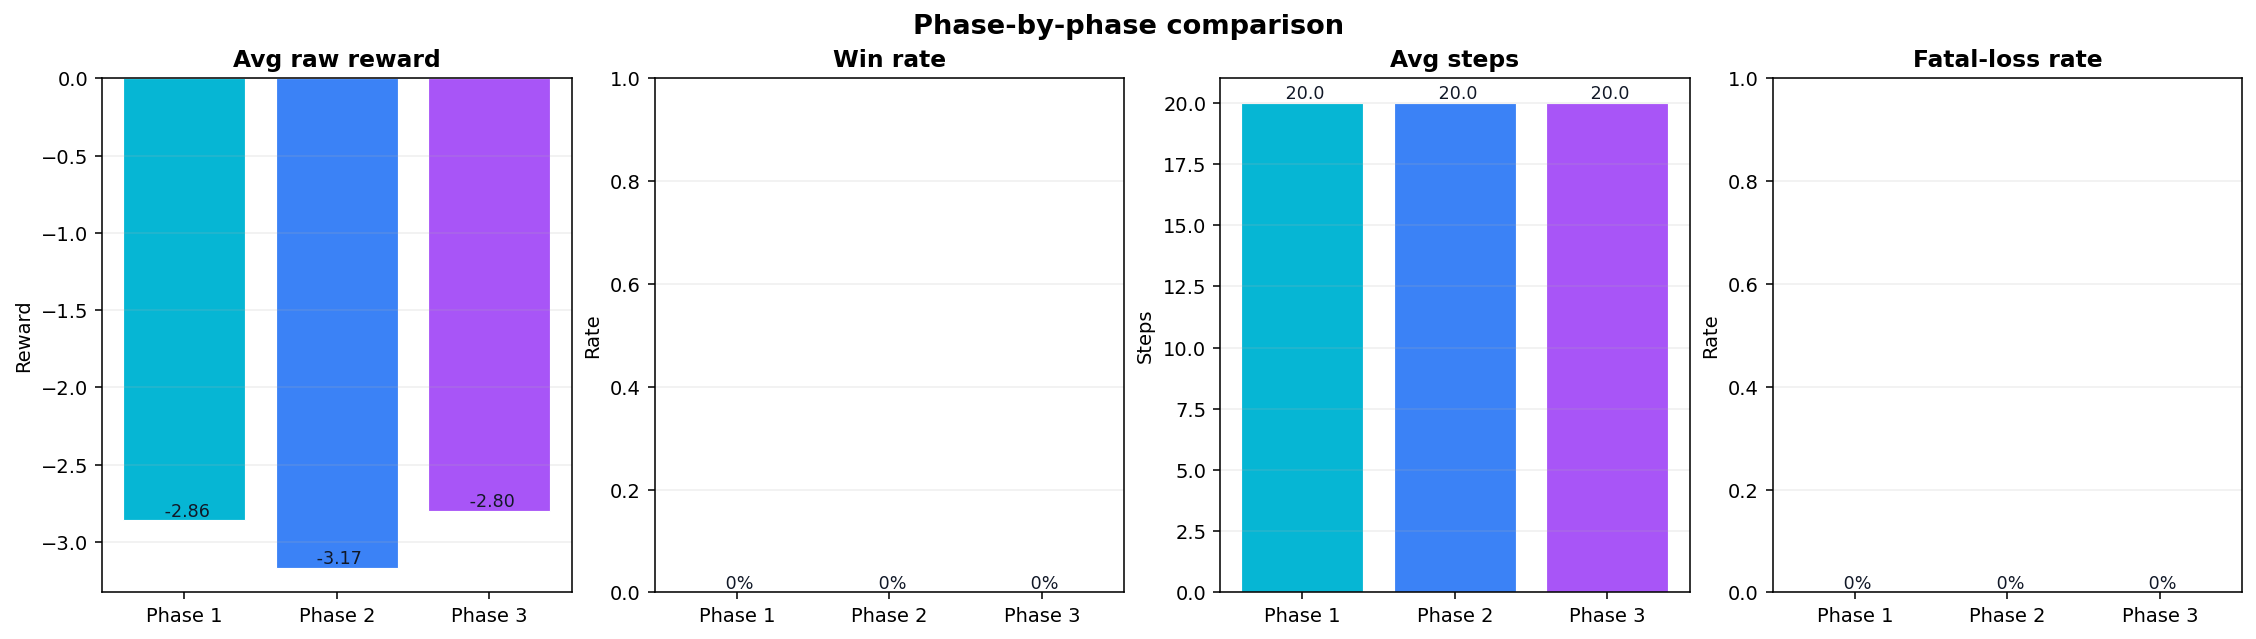

In [5]:
# === CELL 15 — Per-phase training dashboards ===
from ER_MAP.plotting import plot_per_phase_dashboards
from IPython.display import Image, display, Markdown

PLOTS_DIR = f"{OUTPUT_DIR}/plots"
written = plot_per_phase_dashboards(
    metrics_path=f"{OUTPUT_DIR}/training_metrics.json",
    output_dir=PLOTS_DIR,
)

print(f"Saved {len(written)} chart(s) to {PLOTS_DIR}:")
for name, path in written.items():
    size_kb = os.path.getsize(path) / 1024
    print(f"  {name:<28s} -> {path}  ({size_kb:.0f} KB)")

# Display each chart inline so the operator sees them without leaving Kaggle.
ordered = (sorted(k for k in written if k.startswith("phase"))
           + ["all_phases_overview", "all_phases_comparison"])
for key in ordered:
    if key not in written:
        continue
    display(Markdown(f"### {key.replace('_', ' ').title()}"))
    display(Image(filename=written[key]))

In [ ]:
# === CELL 16 — Push plots to HF Hub ===
if HF_PUSH_REPO and "<your-username>" not in HF_PUSH_REPO:
    push_checkpoint_to_hub(PLOTS_DIR, HF_PUSH_REPO,
                           commit_message="per-phase training plots")
    print(f"Plots pushed: https://huggingface.co/{HF_PUSH_REPO}/tree/main")
else:
    print("HF_PUSH_REPO not configured — plots stay only in /kaggle/working/.")